# Phase 1: Exploratory Data Analysis

This notebook explores the locally extracted HAM10000 dataset in more detail. It inspects demographic fields, lesion-level multiplicity, image-size variation, and class balance, then saves plots and summaries for the final report.

The purpose is to understand the raw data before any preprocessing or model training decisions are made.

In [8]:
from pathlib import Path
import json

import pandas as pd
from PIL import Image

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_root = project_root / "data"
raw_dir = data_root / "raw"
artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

metadata_path = raw_dir / "HAM10000_metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

metadata_df = pd.read_csv(metadata_path)
image_dirs = sorted(path for path in raw_dir.iterdir() if path.is_dir() and "images_part" in path.name.lower())
canonical_image_dirs = [path for path in image_dirs if path.name.startswith("HAM10000_")] or image_dirs
image_index = {}
for image_dir in canonical_image_dirs:
    for image_path in image_dir.glob('*.jpg'):
        image_index[image_path.stem] = image_path

metadata_df['label'] = (metadata_df['dx'] == 'mel').astype(int)
metadata_df['label_name'] = metadata_df['dx']

print(json.dumps({
    'project_root': str(project_root),
    'rows': int(len(metadata_df)),
    'unique_lesions': int(metadata_df['lesion_id'].nunique()),
    'image_dirs': [str(path) for path in canonical_image_dirs],
}, indent=2))

{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "rows": 10015,
  "unique_lesions": 7470,
  "image_dirs": [
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_1",
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2"
  ]
}


Saved class distribution plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_eda_class_distribution.png


,diagnosis,count,percentage
0,nv,6705,66.95
1,mel,1113,11.11
2,bkl,1099,10.97
3,bcc,514,5.13
4,akiec,327,3.27
5,vasc,142,1.42
6,df,115,1.15


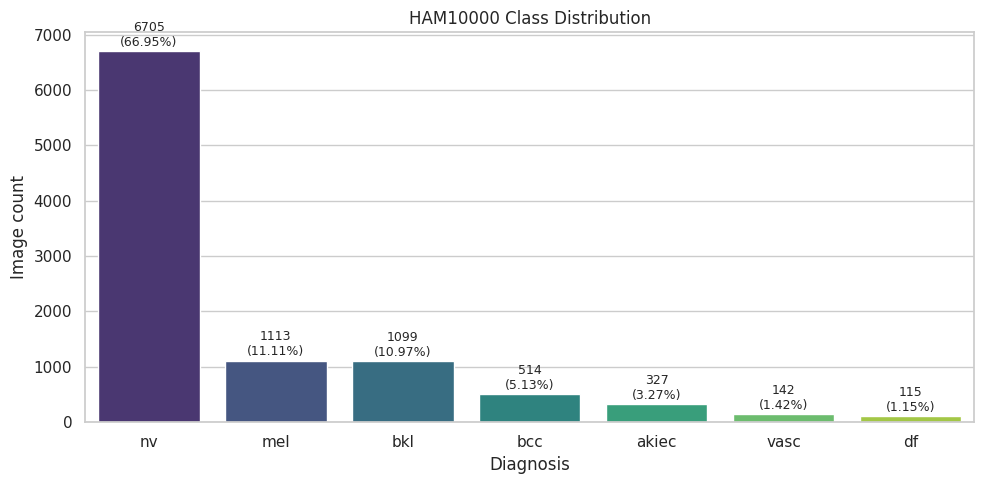

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
class_counts = metadata_df['dx'].value_counts().sort_values(ascending=False)
class_counts_df = class_counts.rename_axis('diagnosis').reset_index(name='count')
class_counts_df['percentage'] = (class_counts_df['count'] / len(metadata_df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=class_counts_df, x='diagnosis', y='count', hue='diagnosis', dodge=False, palette='viridis', legend=False, ax=ax)
ax.set_title('HAM10000 Class Distribution')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Image count')
for index, row in class_counts_df.iterrows():
    ax.text(index, row['count'] + 40, f"{row['count']}\n({row['percentage']}%)", ha='center', va='bottom', fontsize=9)
fig.tight_layout()
class_plot_path = figure_dir / 'ham10000_eda_class_distribution.png'
fig.savefig(class_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved class distribution plot to {class_plot_path}')
class_counts_df

Saved demographic plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_demographics.png
{
  "count": 9958,
  "missing": 57,
  "min": 0.0,
  "max": 85.0,
  "mean": 51.863828077927295,
  "median": 50.0
}


,sex,count
0,male,5406
1,female,4552
2,unknown,57


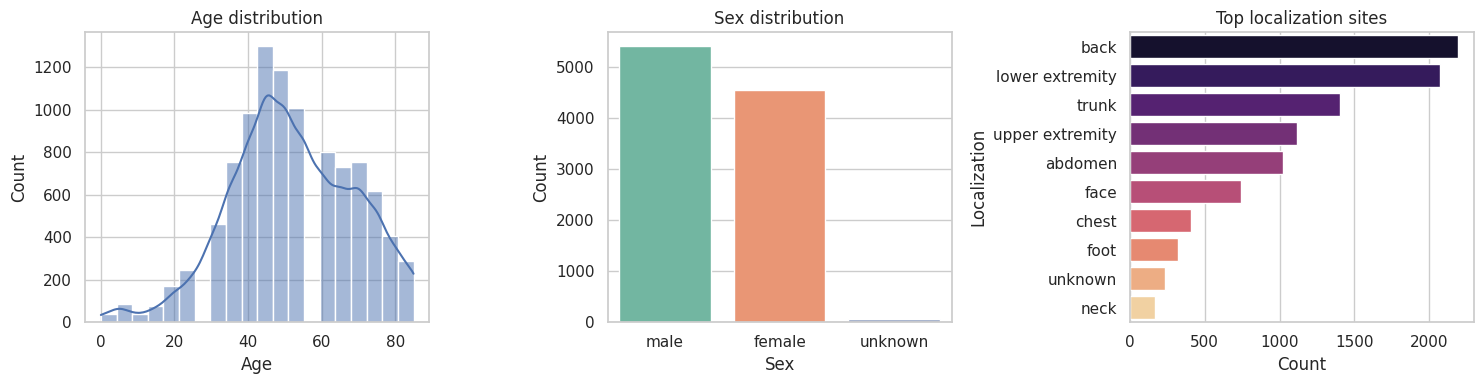

In [10]:
age_series = metadata_df['age'].dropna()
age_stats = {
    'count': int(age_series.count()),
    'missing': int(metadata_df['age'].isna().sum()),
    'min': float(age_series.min()),
    'max': float(age_series.max()),
    'mean': float(age_series.mean()),
    'median': float(age_series.median()),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(age_series, bins=20, kde=True, ax=axes[0], color='#4c72b0')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sex_counts = metadata_df['sex'].value_counts().reset_index()
sex_counts.columns = ['sex', 'count']
sns.barplot(data=sex_counts, x='sex', y='count', hue='sex', dodge=False, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Sex distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

loc_counts = metadata_df['localization'].value_counts().head(10).reset_index()
loc_counts.columns = ['localization', 'count']
sns.barplot(data=loc_counts, y='localization', x='count', hue='localization', dodge=False, palette='magma', legend=False, ax=axes[2])
axes[2].set_title('Top localization sites')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Localization')

fig.tight_layout()
demographic_plot_path = figure_dir / 'ham10000_demographics.png'
fig.savefig(demographic_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved demographic plot to {demographic_plot_path}')
print(json.dumps(age_stats, indent=2))
sex_counts

Saved sample image grid to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_sample_images.png


,diagnosis,image_id,path,width,height
0,nv,ISIC_0024698,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
1,mel,ISIC_0025964,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
2,bkl,ISIC_0027419,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
3,bcc,ISIC_0028155,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
4,akiec,ISIC_0029417,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
5,vasc,ISIC_0031197,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450
6,df,ISIC_0027008,/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data...,600,450


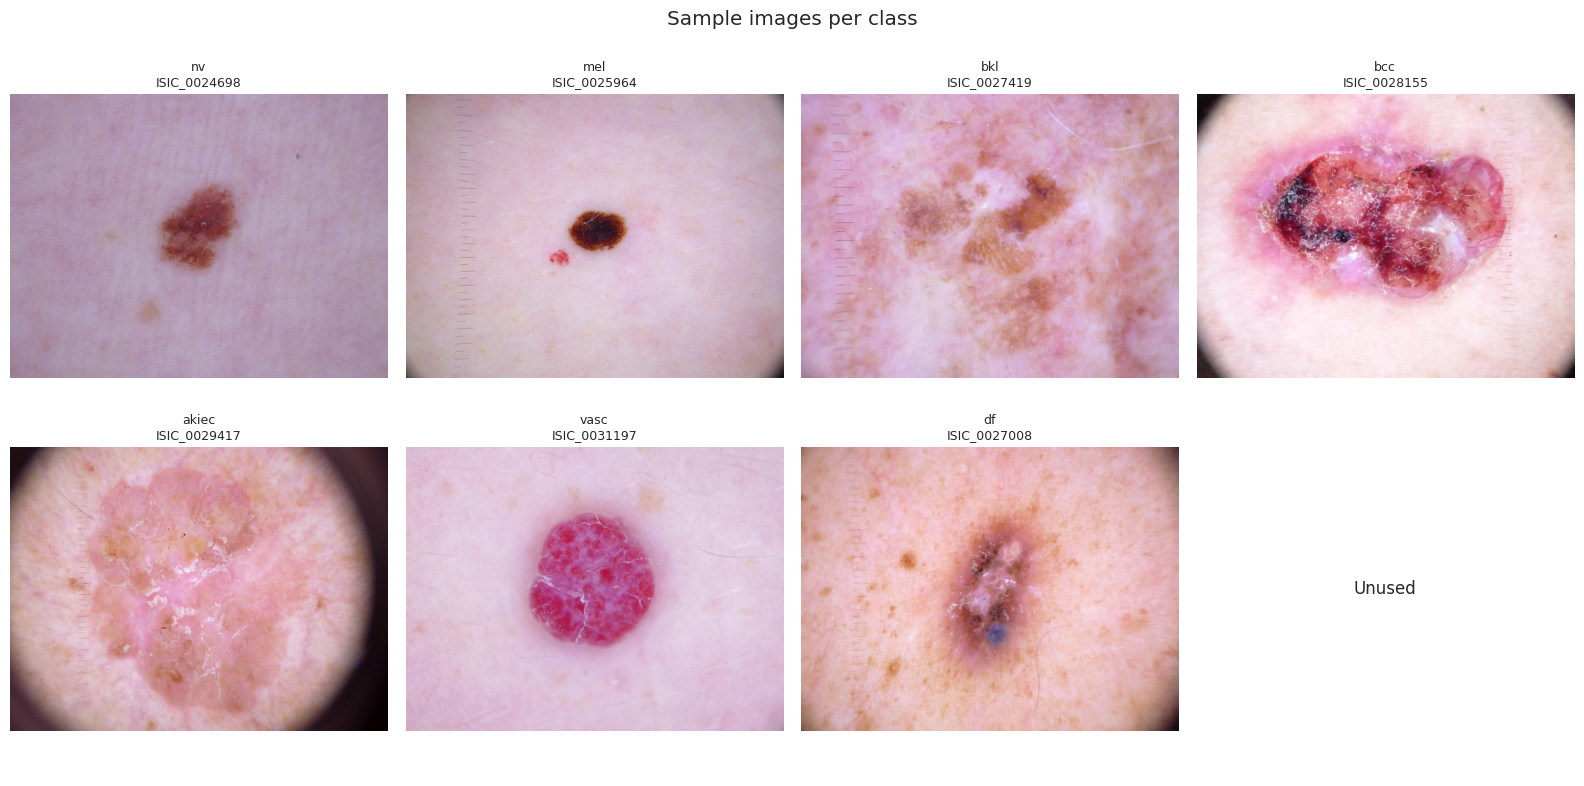

In [11]:
def locate_image(image_id: str):
    return image_index.get(image_id)

sample_rows = []
for diagnosis in class_counts_df['diagnosis']:
    row = metadata_df[metadata_df['dx'] == diagnosis].iloc[0]
    image_path = locate_image(row['image_id'])
    if image_path is None:
        continue
    with Image.open(image_path) as image:
        width, height = image.size
    sample_rows.append({
        'diagnosis': diagnosis,
        'image_id': row['image_id'],
        'path': str(image_path),
        'width': width,
        'height': height,
    })

sample_df = pd.DataFrame(sample_rows)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax in axes:
    ax.axis('off')

for index, (_, row) in enumerate(sample_df.iterrows()):
    with Image.open(row['path']) as image:
        axes[index].imshow(image)
    axes[index].set_title(f"{row['diagnosis']}\n{row['image_id']}", fontsize=9)
    axes[index].axis('off')

if len(axes) > len(sample_df):
    axes[-1].text(0.5, 0.5, 'Unused', ha='center', va='center')

fig.suptitle('Sample images per class', y=0.98)
fig.tight_layout()
sample_plot_path = figure_dir / 'ham10000_sample_images.png'
fig.savefig(sample_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved sample image grid to {sample_plot_path}')
sample_df

Saved image size plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_image_size_distribution.png
{
  "count": 10015,
  "width_min": 600,
  "width_max": 600,
  "width_mean": 600.0,
  "height_min": 450,
  "height_max": 450,
  "height_mean": 450.0
}


,image_id,width,height
0,ISIC_0024306,600,450
1,ISIC_0024307,600,450
2,ISIC_0024308,600,450
3,ISIC_0024309,600,450
4,ISIC_0024310,600,450


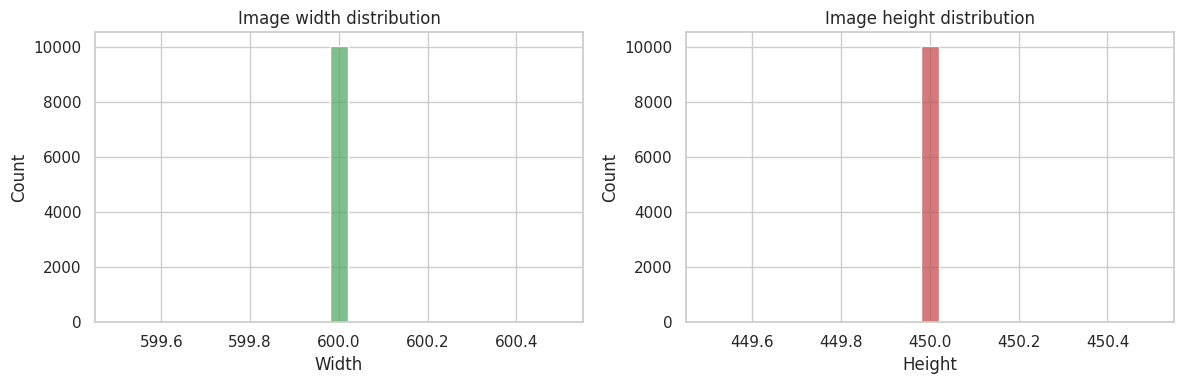

In [12]:
image_sizes = []
for image_path in image_index.values():
    with Image.open(image_path) as image:
        width, height = image.size
    image_sizes.append({'image_id': image_path.stem, 'width': width, 'height': height})

image_size_df = pd.DataFrame(image_sizes)
image_size_stats = {
    'count': int(len(image_size_df)),
    'width_min': int(image_size_df['width'].min()),
    'width_max': int(image_size_df['width'].max()),
    'width_mean': float(image_size_df['width'].mean()),
    'height_min': int(image_size_df['height'].min()),
    'height_max': int(image_size_df['height'].max()),
    'height_mean': float(image_size_df['height'].mean()),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(image_size_df['width'], bins=25, ax=axes[0], color='#55a868')
axes[0].set_title('Image width distribution')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Count')

sns.histplot(image_size_df['height'], bins=25, ax=axes[1], color='#c44e52')
axes[1].set_title('Image height distribution')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Count')

fig.tight_layout()
image_size_plot_path = figure_dir / 'ham10000_image_size_distribution.png'
fig.savefig(image_size_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved image size plot to {image_size_plot_path}')
print(json.dumps(image_size_stats, indent=2))
image_size_df.head()

Saved lesion count plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_images_per_lesion.png
{
  "lesions": 7470,
  "min_images_per_lesion": 1,
  "max_images_per_lesion": 6,
  "mean_images_per_lesion": 1.3406961178045516,
  "median_images_per_lesion": 1.0
}


,lesion_id,image_count
0,HAM_0000000,2
1,HAM_0000001,1
2,HAM_0000002,3
3,HAM_0000003,1
4,HAM_0000004,1


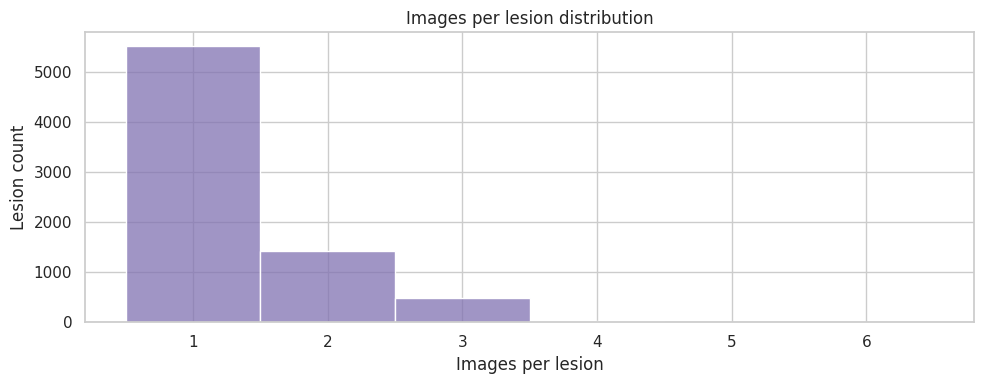

In [13]:
lesion_counts = metadata_df.groupby('lesion_id').size().reset_index(name='image_count')
lesion_count_stats = {
    'lesions': int(len(lesion_counts)),
    'min_images_per_lesion': int(lesion_counts['image_count'].min()),
    'max_images_per_lesion': int(lesion_counts['image_count'].max()),
    'mean_images_per_lesion': float(lesion_counts['image_count'].mean()),
    'median_images_per_lesion': float(lesion_counts['image_count'].median()),
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(lesion_counts['image_count'], bins=10, discrete=True, ax=ax, color='#8172b2')
ax.set_title('Images per lesion distribution')
ax.set_xlabel('Images per lesion')
ax.set_ylabel('Lesion count')
fig.tight_layout()
lesion_plot_path = figure_dir / 'ham10000_images_per_lesion.png'
fig.savefig(lesion_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved lesion count plot to {lesion_plot_path}')
print(json.dumps(lesion_count_stats, indent=2))
lesion_counts.head()

In [14]:
summary = {
    'rows': int(len(metadata_df)),
    'unique_lesions': int(metadata_df['lesion_id'].nunique()),
    'class_counts': class_counts_df.to_dict(orient='records'),
    'age_stats': age_stats,
    'image_size_stats': image_size_stats,
    'lesion_count_stats': lesion_count_stats,
}

summary_path = artifact_dir / 'ham10000_eda_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(f'Saved EDA summary to {summary_path}')
summary

Saved EDA summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/ham10000_eda_summary.json


{'rows': 10015,
 'unique_lesions': 7470,
 'class_counts': [{'diagnosis': 'nv', 'count': 6705, 'percentage': 66.95},
  {'diagnosis': 'mel', 'count': 1113, 'percentage': 11.11},
  {'diagnosis': 'bkl', 'count': 1099, 'percentage': 10.97},
  {'diagnosis': 'bcc', 'count': 514, 'percentage': 5.13},
  {'diagnosis': 'akiec', 'count': 327, 'percentage': 3.27},
  {'diagnosis': 'vasc', 'count': 142, 'percentage': 1.42},
  {'diagnosis': 'df', 'count': 115, 'percentage': 1.15}],
 'age_stats': {'count': 9958,
  'missing': 57,
  'min': 0.0,
  'max': 85.0,
  'mean': 51.863828077927295,
  'median': 50.0},
 'image_size_stats': {'count': 10015,
  'width_min': 600,
  'width_max': 600,
  'width_mean': 600.0,
  'height_min': 450,
  'height_max': 450,
  'height_mean': 450.0},
 'lesion_count_stats': {'lesions': 7470,
  'min_images_per_lesion': 1,
  'max_images_per_lesion': 6,
  'mean_images_per_lesion': 1.3406961178045516,
  'median_images_per_lesion': 1.0}}